This script simulates spacecraft telemetry data, integrating information regarding temperature, pressure, energy levels, and the status of critical systems.
The telemetry is organized in a tabular format (DataFrame) and saved as a CSV file for subsequent computational analysis.

In [162]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

ROWS = 1000
START_TIME = datetime(2026, 3, 14, 10, 0, 0)
OUTPUT_PATH = "telemetry_dataset.csv"

def generate_telemetry(rows, start_time):
    timestamps = [start_time + timedelta(seconds=i) for i in range(rows)]

    temp_internal = np.clip(
        34 + np.cumsum(np.random.normal(0.05, 0.2, rows)),
        30, 85
    )

    temp_external = np.clip(
        18 + np.random.normal(0, 1.2, rows),
        -20, 40
    )

    energy_level = np.clip(
        100 - np.linspace(0, 40, rows) + np.random.normal(0, 0.5, rows),
        0, 100
    )

    tank_pressure = np.clip(
        250 - np.linspace(0, 40, rows) + np.random.normal(0, 0.8, rows),
        150, 260
    )

    # Sistemas binários
    structural_integrity = np.ones(rows, dtype=int)
    structural_integrity[np.random.choice(rows, size=5, replace=False)] = 0

    def generate_status():
        arr = np.ones(rows, dtype=int)
        arr[np.random.choice(rows, size=3, replace=False)] = 0
        return arr

    df = pd.DataFrame({
        "timestamp": timestamps,
        "temp_internal_c": temp_internal.round(2),
        "temp_external_c": temp_external.round(2),
        "structural_integrity": structural_integrity,
        "energy_level_pct": energy_level.round(2),
        "tank_pressure_bar": tank_pressure.round(2),
        "avionics_status": generate_status(),
        "propulsion_status": generate_status(),
        "navigation_status": generate_status(),
        "comms_status": generate_status()
    })

    return df

df = generate_telemetry(ROWS, START_TIME)
df.head()

df.to_csv(OUTPUT_PATH, index=False)
print(f"Dataset salvo em: {OUTPUT_PATH}")


Dataset salvo em: telemetry_dataset.csv


The script aims to load a flight telemetry dataset (telemetry_dataset.csv) and perform an initial visualization of the first entries, using Python and data analysis and visualization libraries.

In [163]:
# Importações
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (14, 6)

# Carregar dataset
df = pd.read_csv("telemetry_dataset.csv", parse_dates=["timestamp"])
df.head()

,timestamp,temp_internal_c,temp_external_c,structural_integrity,energy_level_pct,tank_pressure_bar,avionics_status,propulsion_status,navigation_status,comms_status
0,2026-03-14 10:00:00,34.13,16.38,1,99.75,249.59,1,1,1,1
1,2026-03-14 10:00:01,34.47,17.77,1,100.00,249.77,1,1,1,1
2,2026-03-14 10:00:02,34.66,18.35,1,100.00,248.93,1,1,1,1
3,2026-03-14 10:00:03,34.59,18.43,1,99.33,250.14,1,1,1,1
4,2026-03-14 10:00:04,34.62,16.86,1,100.00,249.86,1,1,1,1


In [164]:
# Statistics Describe

df.describe()

,timestamp,temp_internal_c,temp_external_c,structural_integrity,energy_level_pct,tank_pressure_bar,avionics_status,propulsion_status,navigation_status,comms_status
count,1000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2026-03-14 10:08:19.500000,64.104420,18.000870,0.995000,80.010240,230.018620,0.997000,0.997000,0.997000,0.997000
min,2026-03-14 10:00:00,34.130000,14.400000,0.000000,59.730000,209.060000,0.000000,0.000000,0.000000,0.000000
25%,2026-03-14 10:04:09.750000,51.472500,17.240000,1.000000,70.175000,220.032500,1.000000,1.000000,1.000000,1.000000
50%,2026-03-14 10:08:19.500000,66.130000,18.000000,1.000000,79.900000,229.940000,1.000000,1.000000,1.000000,1.000000
75%,2026-03-14 10:12:29.250000,76.952500,18.772500,1.000000,90.122500,240.190000,1.000000,1.000000,1.000000,1.000000
max,2026-03-14 10:16:39,85.000000,21.700000,1.000000,100.000000,250.580000,1.000000,1.000000,1.000000,1.000000
std,NaN,15.278613,1.152135,0.070569,11.578827,11.539404,0.054717,0.054717,0.054717,0.054717


In [165]:
# Mission Confi

TOTAL_CAPACITY_KWH = 500
TAKEOFF_POWER_KW = 120
ENERGY_LOSS = 0.08
INITIAL_PAYLOAD_KG = 800

Energy Metrics (calculate_energy_metrics)

This function calculates the key indicators related to the energy available and consumed during the mission.

Outputs: A dictionary containing:

initial_energy_pct: initial energy percentage
energy_available_kwh: available energy (kWh)
energy_usable_kwh: usable energy (kWh)
initial_autonomy_h: initial autonomy (h)
adjusted_energy_usable_kwh: adjusted energy (considering thermal losses)
adjusted_autonomy_h: adjusted autonomy (h)
thermal_loss_factor: thermal loss factor

Theoretical Reference: Energy efficiency in embedded systems, thermal loss management, and energy consumption optimization

In [166]:
# =========================================
# 4. ENERGY METRICS
# =========================================
def calculate_energy_metrics(df):

    initial_energy_pct = float(df["energy_level_pct"].iloc[0])

    energy_available = TOTAL_CAPACITY_KWH * (initial_energy_pct / 100.0)
    energy_usable = energy_available * (1.0 - ENERGY_LOSS)

    initial_autonomy = energy_usable / TAKEOFF_POWER_KW

    temp_internal_mean = float(df["temp_internal_c"].mean())
    thermal_loss_factor = 1.0 + ((temp_internal_mean - 30.0) / 100.0)

    adjusted_energy_usable = energy_usable / thermal_loss_factor
    adjusted_autonomy = adjusted_energy_usable / TAKEOFF_POWER_KW

    return {
        "initial_energy_pct": initial_energy_pct,
        "energy_available_kwh": energy_available,
        "energy_usable_kwh": energy_usable,
        "initial_autonomy_h": initial_autonomy,
        "adjusted_energy_usable_kwh": adjusted_energy_usable,
        "adjusted_autonomy_h": adjusted_autonomy,
        "thermal_loss_factor": thermal_loss_factor
    }

System Metrics (calculate_system_metrics)

Calculates the overall condition of the ship's critical systems.

Outputs: A dictionary containing:

avg_pressure_bar: average tank pressure
fuel_consumption_index: consumption index
structural_ok: structural integrity
systems_ok: critical systems status
mission_status: final result of the mission check

Theoretical Reference: The importance of structural integrity and critical systems for a safe launch.

In [167]:
# =========================================
# 5. SYSTEM METRICS
# =========================================
def calculate_system_metrics(df):

    avg_pressure = float(df["tank_pressure_bar"].mean())

    fuel_consumption_index = TAKEOFF_POWER_KW * (1.0 + (INITIAL_PAYLOAD_KG / 1000.0))

    structural_ok = bool(df["structural_integrity"].all())

    systems_ok = all([
        df["avionics_status"].all(),
        df["propulsion_status"].all(),
        df["navigation_status"].all(),
        df["comms_status"].all()
    ])

    mission_status = "🚀 READY FOR TAKEOFF" if structural_ok and systems_ok else "❌ LAUNCH ABORTED"

    return {
        "avg_pressure_bar": avg_pressure,
        "fuel_consumption_index": fuel_consumption_index,
        "structural_ok": structural_ok,
        "systems_ok": systems_ok,
        "mission_status": mission_status
    }


Loss Metrics (calculate_loss_metrics)

Evaluates energy losses and auxiliary loads.

Outputs: DataFrame with the following columns:

thermal_loss
mechanical_loss
auxiliary_load
energy_level_pct

Theoretical Reference: Energy loss management, consumption optimization in critical systems

Correlations (calculate_correlations)

Calculates the correlation matrix among loss metrics to identify significant relationships.

Outputs: Correlation matrix (DataFrame)

Theoretical Reference: Correlation analysis to detect dependencies between physical and computational variables

This set of functions enables:

Evaluating the spacecraft's energy autonomy, taking thermal conditions into account;
Monitoring structural and operational integrity;
Quantifying energy losses and auxiliary system loads;
Establishing relationships between critical variables for performance and risk analyses.

In [168]:
# =========================================
# 6. LOSS METRICS
# =========================================
def calculate_loss_metrics(df):

    loss_df = pd.DataFrame(index=df.index)

    loss_df["thermal_loss"] = (df["temp_internal_c"] - 30).clip(lower=0)

    loss_df["mechanical_loss"] = abs(
        df["tank_pressure_bar"] - df["tank_pressure_bar"].mean()
    )

    loss_df["auxiliary_load"] = (
        df["avionics_status"] +
        df["navigation_status"] +
        df["comms_status"]
    )

    loss_df["energy_level_pct"] = df["energy_level_pct"]

    return loss_df

# =========================================
# 7. CORRELATION
# =========================================
def calculate_correlations(loss_df):
    return loss_df.corr(numeric_only=True)

In [169]:
# =========================================
# 8. EXECUTION
# =========================================
energy_metrics = calculate_energy_metrics(df)
system_metrics = calculate_system_metrics(df)

loss_df = calculate_loss_metrics(df)
corr_matrix = calculate_correlations(loss_df)

print("Energy Metrics",energy_metrics)

print("System Metrics",system_metrics)

print("Loss",loss_df)

print("Correlation Loss",corr_matrix)


Energy Metrics {'initial_energy_pct': 99.75, 'energy_available_kwh': 498.75, 'energy_usable_kwh': 458.85, 'initial_autonomy_h': 3.82375, 'adjusted_energy_usable_kwh': 342.1587446558436, 'adjusted_autonomy_h': 2.85132287213203, 'thermal_loss_factor': 1.3410442}
System Metrics {'avg_pressure_bar': 230.01862, 'fuel_consumption_index': 216.0, 'structural_ok': False, 'systems_ok': False, 'mission_status': '❌ LAUNCH ABORTED'}
Loss      thermal_loss  mechanical_loss  auxiliary_load  energy_level_pct
0            4.13         19.57138               3             99.75
1            4.47         19.75138               3            100.00
2            4.66         18.91138               3            100.00
3            4.59         20.12138               3             99.33
4            4.62         19.84138               3            100.00
..            ...              ...             ...               ...
995         55.00         17.75862               3             60.50
996         55.00  

Decision Engine Data

The `export_results.py` module aims to consolidate telemetry data, system energy and performance metrics, losses, and correlations into a structured JSON file compatible with the `decision_engine`. It enables the organized export of information generated during the pre-analysis of flight data or simulations for the Aurora Siger mission, ensuring that subsequent analyses and decision engines can consume the results consistently.

Main Function
`export_results(energy_metrics, system_metrics, loss_df, corr_matrix)`

Responsible for exporting the consolidated metrics data to JSON.

In [170]:
import json
from pathlib import Path

# Caminho para salvar os dados processados
OUTPUT_PATH = Path("processed.json")

def export_results(energy_metrics, system_metrics, loss_df, corr_matrix):
    """
    Exporta métricas de energia, sistema, perdas e correlações para JSON
    compatível com decision_engine.
    """
    data = {
        "energy": energy_metrics,
        "system": system_metrics,
        "loss": {
            "thermal": float(loss_df['thermal_loss'].mean()),
            "mechanical": float(loss_df['mechanical_loss'].mean()),
            "aux": float(loss_df['auxiliary_load'].mean())
        },
        "correlation": corr_matrix.to_dict()
    }

    with open(OUTPUT_PATH, "w") as f:
        json.dump(data, f, indent=4)

    print("Data exported to:", OUTPUT_PATH)

In [171]:
export_results(energy_metrics, system_metrics, loss_df, corr_matrix)

Data exported to: processed.json


Decision Engine

The rules module contains functions that evaluate various aspects of space mission performance, based on telemetry data and energy metrics.
Each function returns penalties (consisting of a name and a value) if certain critical conditions are met, enabling the decision system to assess risks and determine
whether the launch should be approved or aborted.

Energy Rules (energy_rules)
Description:

Evaluates the available and usable energy metrics for the spacecraft.
adjusted_autonomy: remaining autonomy adjusted for losses and constraints (in hours).
A 25-point penalty applies if this value is less than 2.5 hours.
adjusted_energy_usable: adjusted usable energy (in kWh or %).
A 20-point penalty applies if this value is less than 90 units.

Conceptual Reference:

Based on principles of energy efficiency, conservation, and critical resource management.

In [172]:
# ======================
# Rules
# ======================
def energy_rules(data):
    energy = data["energy"]
    penalties = []

    if energy["adjusted_autonomy"] < 2.5:
        penalties.append(("Low autonomy", 25))

    if energy["adjusted_energy_usable"] < 90:
        penalties.append(("Low usable energy", 20))
        
    return penalties

Loss Rules (loss_rules)

Description:

Evaluates energy and mechanical losses that impact the ship's performance.
thermal: accumulated thermal loss (%)
25-point penalty if exceeding 25%.
mechanical: detected mechanical instability (in any vibration index or structural tolerance)
15-point penalty if exceeding 12%.

Conceptual Reference:

Corresponds to the analysis of heat dissipation, processor cooling, and entropy limits.

In [173]:
def loss_rules(data):
    loss = data["loss"]
    penalties = []

    if loss["thermal"] > 25:
        penalties.append(("High thermal loss", 25))

    if loss["mechanical"] > 12:
        penalties.append(("Mechanical instability", 15))

    return penalties

Correlation Rules (correlation_rules)

Description:

Analyzes the relationship between critical variables to detect situations of systemic risk.
thermal_loss vs energy_level_pct: Correlation between thermal loss and remaining energy level.
A 40-point penalty is applied if there is an extremely negative correlation (< -0.9), indicating that thermal losses are rapidly depleting critical energy.

Conceptual Reference:

Relates energy efficiency to the intelligent monitoring of physical variables.

In [174]:
def correlation_rules(data):
    corr = data["correlation"]
    penalties = []

    thermal_corr = corr["thermal_loss"]["energy_level_pct"]

    if thermal_corr < -0.9:
        penalties.append(("Critical thermal-energy coupling", 40))
        
    return penalties

System Rules (system_rules)

Description:

Evaluates the overall system status and mission integrity.
mission_status: A string indicating the current state of the mission.
A 50-point penalty applies if it contains "ABORTED," signaling a critical failure that prevents the safe continuation of the operation.

Conceptual Reference:

Based on spacecraft survival protocols and critical takeoff decisions.

In [175]:
def system_rules(data):
    system = data["system"]
    penalties = []

    if "ABORTED" in system["mission_status"]:
        penalties.append(("System integrity failure", 50))

    return penalties

Integration and Evaluation Flow
All functions return a list of tuples (penalty_name, value).
A central evaluator (`evaluate`) sums or weights these penalties to generate a final risk score, determining whether takeoff is safe.

In [176]:
# ======================
# Evaluation
# ======================
def evaluate(penalties):
    base_score = 100
    reasons = []

    for reason, penalty in penalties:
        base_score -= penalty
        reasons.append(reason)

    if base_score >= 70:
        decision = "GO"
        color = "#00ffcc"
    elif base_score >= 40:
        decision = "WARNING"
        color = "#ffaa00"
    else:
        decision = "ABORT"
        color = "#ff4d4d"

    return decision, color, base_score, reasons

The decision engine is responsible for consolidating the metrics and analyses collected during the mission's pre-takeoff phase.
It evaluates whether the spacecraft is "READY FOR TAKEOFF" or if the takeoff must be aborted.

It integrates checks across multiple critical domains:

Power – autonomy and energy efficiency.
System losses and performance – analysis of consumption, dissipation, and efficiency metrics.
Correlation between critical variables – consistency between sensors and telemetry signals.
Onboard system health and performance – integrity of modules and sensors.

In [177]:
# ======================
# Decision Engine
# ======================
def decision_engine(data):
    penalties = []
    penalties += energy_rules(data)
    penalties += loss_rules(data)
    penalties += correlation_rules(data)
    penalties += system_rules(data)

    return evaluate(penalties)


In [178]:
import json
from pathlib import Path

PROCESSED_DATA = Path("processed.json")


def load_processed_data(path: Path) -> dict:
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")
    
    with open(path, "r") as f:
        return json.load(f)


def build_engine_input(raw: dict) -> dict:
    try:
        return {
            "energy": {
                "adjusted_autonomy": raw["energy"]["adjusted_autonomy_h"],
                "adjusted_energy_usable": raw["energy"]["adjusted_energy_usable_kwh"]
            },
            "loss": {
                "thermal": raw["loss"]["thermal"],
                "mechanical": raw["loss"]["mechanical"]
            },
            "correlation": {
                "thermal_loss": {
                    "energy_level_pct": raw["correlation"]["thermal_loss"]["energy_level_pct"]
                }
            },
            "system": {
                "mission_status": raw["system"]["mission_status"]
            }
        }
    except KeyError as e:
        raise ValueError(f"Missing expected key in processed data: {e}")


def run_decision_pipeline():
    raw = load_processed_data(PROCESSED_DATA)
    engine_input = build_engine_input(raw)

    decision, color, score, reasons = decision_engine(engine_input)

    print("\n=== DECISION ENGINE OUTPUT ===")
    print(f"Decision     : {decision}")
    print(f"Score        : {score:.2f}")
    print(f"Color code   : {color}")
    
    print("\nReasons:")
    for i, reason in enumerate(reasons, 1):
        print(f"  {i}. {reason}")

run_decision_pipeline()


=== DECISION ENGINE OUTPUT ===
Decision     : ABORT
Score        : -15.00
Color code   : #ff4d4d

Reasons:
  1. High thermal loss
  2. Critical thermal-energy coupling
  3. System integrity failure


In [184]:
def show_table(metrics, title):
    df = pd.DataFrame.from_dict(metrics, orient="index", columns=["Value"])
    # formata números sem usar style
    df["Value"] = df["Value"].apply(lambda x: f"{x:.2f}" if isinstance(x, (int, float)) else x)
    print(title)
    display(df)

In [185]:
show_table(energy_metrics, "Energy Metrics")

Energy Metrics


,Value
initial_energy_pct,99.75
energy_available_kwh,498.75
energy_usable_kwh,458.85
initial_autonomy_h,3.82
adjusted_energy_usable_kwh,342.16
adjusted_autonomy_h,2.85
thermal_loss_factor,1.34


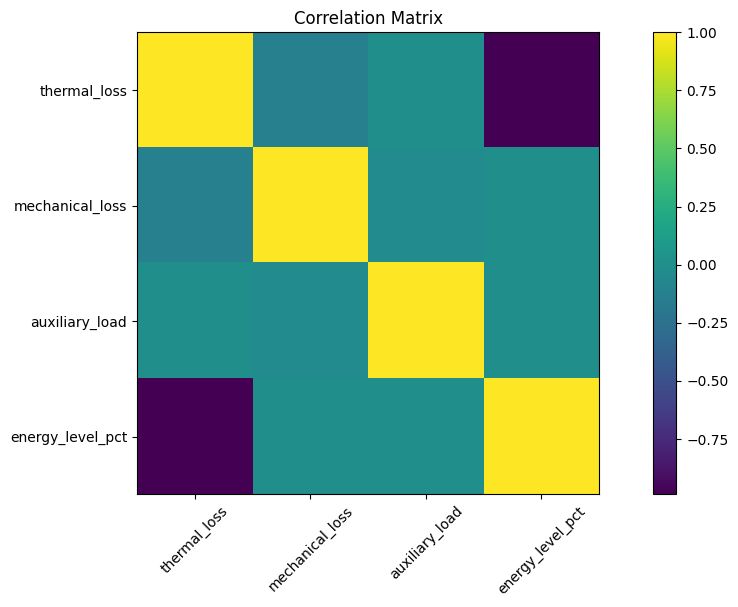

In [186]:
import matplotlib.pyplot as plt

plt.imshow(corr_matrix)
plt.colorbar()
plt.title("Correlation Matrix")
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.show()